In [ ]:

import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment
import glob
import os

CARPETA = 'SALIDAS_HIPRA'
PATH = os.path.join(CARPETA, '*.csv')

archivos = glob.glob(PATH)

tablas = []

# Leemos los excels que hayan en la carpeta SALIDAS_HIPRA
for archivo in archivos:
  print(f"Leyendo datos de: {os.path.basename(archivo)}...")
  df = pd.read_csv(archivo, sep=';', encoding='latin1', dtype=str)
  tablas.append(df)

# Unimos los datos

if tablas:
  salidas = pd.concat(tablas, ignore_index=True)
  print(f"Se han fusionado {len(archivos)} archivos con éxito. Total de filas: {len(salidas)}.")
else:
  print("La carpeta está vacía. Mete algún Excel para calcular.")


Leyendo datos de: salidas.csv...
Se han fusionado 1 con éxito. Total de filas: 4533.


# Análisis ABC (gasto)

In [ ]:

print(salidas.head())
print(salidas.info())

    Material                DescripciÃ³n del material Lote Cantidad  \
0  9037343,0       BATERIA -80Âºc 12V 1.2AH TERMOFISH  NaN     -1,0   
1  9005995,0  BAUSCH+STROBEL REF: 32805027 O-RING B&S  NaN     -4,0   
2  9039794,0        BOMBA DE VACIO 2BL2041-2AK50-6B-Z  NaN     -1,0   
3  9028783,0         CLAVIJA SCHUCO 230V CONEXION SAI  NaN     -2,0   
4  9016868,0     JUNTA BH TORICA 8 X 422 SILICONA+FDA  NaN     -1,0   

  Unidad medida base Clase de movimiento Texto de clase de movimiento  \
0                 UN                 Z61                          NaN   
1                 UN                 Z61                          NaN   
2                 UN                 Z61                          NaN   
3                 UN                 Z61                          NaN   
4                 UN                 Z61                          NaN   

  Centro de coste AlmacÃ©n Fecha contabiliz.  ... Ejerc.documento mat. Pedido  \
0             NaN   1010,0        2026-03-24  ...    

In [ ]:
# Limpieza

salidas['Importe ML'] = salidas['Importe ML'].str.replace('.', '', regex=False)
salidas['Importe ML'] = salidas['Importe ML'].str.replace(',', '.', regex=False)
salidas['Gasto absoluto'] = pd.to_numeric(salidas['Importe ML'], errors = 'coerce').abs()

salidas['Cantidad'] = salidas['Cantidad'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
salidas['Cantidad'] = pd.to_numeric(salidas['Cantidad'], errors='coerce').abs()

salidas = salidas[salidas['Gasto absoluto'] > 0]




In [ ]:
# Agrupar

abc = salidas.groupby(['Material', 'DescripciÃ³n del material']).agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Gasto_Total=('Gasto absoluto', 'sum')
    ).reset_index()

abc['Descripcion del material'] = abc['DescripciÃ³n del material']

abc = abc.sort_values(by='Gasto_Total', ascending=False).reset_index(drop=True)

# Porcentajes
abc['Porcentaje'] = abc['Gasto_Total'] / abc['Gasto_Total'].sum() * 100
abc['Porcentaje'] = abc['Porcentaje'].round(2)
abc['Porcentaje acumulado'] = abc['Porcentaje'].cumsum()

print(abc.head())

abc['Precio'] = abc['Gasto_Total'] / abc['Cantidad_Total']

    Material                DescripciÃ³n del material  Cantidad_Total  \
0  9033888,0  CABEZA DE CHOQUE 9514-8353-022 GEA NIRO            24.0   
1  9005203,0         MEMBRANA GEMU MG8 EPDM 600/8M/17          2757.0   
2  9005165,0  MEMBRANA GEMU MG25 PTFE/EPDM 600/25M/5M           363.0   
3  9005204,0       MEMBRANA GEMU MG25 EPDM 600/25M/17          1075.0   
4  9005166,0  MEMBRANA GEMU DN40 PTFE/EPDM 600/40M/5M           182.0   

   Gasto_Total                 Descripcion del material  Porcentaje  \
0     50418.08  CABEZA DE CHOQUE 9514-8353-022 GEA NIRO        5.03   
1     40967.42         MEMBRANA GEMU MG8 EPDM 600/8M/17        4.09   
2     40719.30  MEMBRANA GEMU MG25 PTFE/EPDM 600/25M/5M        4.06   
3     32402.45       MEMBRANA GEMU MG25 EPDM 600/25M/17        3.23   
4     29467.75  MEMBRANA GEMU DN40 PTFE/EPDM 600/40M/5M        2.94   

   Porcentaje acumulado  
0                  5.03  
1                  9.12  
2                 13.18  
3                 16.41  
4   

In [ ]:
# Clasificar segun gasto

def clasificar_abc(porcentaje_acumulado):
        if porcentaje_acumulado <= 80:
            return 'A'
        elif porcentaje_acumulado <= 95:
            return 'B'
        else:
            return 'C'

abc['Clasificacion ABC'] = abc['Porcentaje acumulado'].apply(clasificar_abc)
print(abc['Clasificacion ABC'].value_counts())



Clasificacion ABC
C    544
B    192
A    105
Name: count, dtype: int64


# Análisis XYZ (rotación)

In [ ]:
# Clasificamos según frecuencia de salida.
salidas['Fecha contabiliz.'] = pd.to_datetime(salidas['Fecha contabiliz.'], format = 'mixed', dayfirst=True, errors='coerce')
salidas = salidas[salidas['Fecha contabiliz.'].notnull()]

salidas['Año Mes'] = salidas['Fecha contabiliz.'].dt.to_period('M')



In [ ]:
# Clasificamos XYZ

xyz = salidas.groupby(['Material', 'DescripciÃ³n del material']).agg(
        Meses_Distintos = ('Año Mes', 'nunique')).reset_index()

xyz = xyz.sort_values(by='Meses_Distintos', ascending=False).reset_index(drop=True)

print(xyz['Meses_Distintos'].value_counts().sort_index())

def clasificar_xyz(meses):
        if meses >= 7: return 'X'       # Alta rotación para tu fábrica
        elif meses >= 3: return 'Y'     # Rotación media
        else: return 'Z'                # Baja rotación (1 o 2 meses)

xyz['Clasificacion XYZ'] = xyz['Meses_Distintos'].apply(clasificar_xyz)

print(xyz.info())
print(xyz['Clasificacion XYZ'].value_counts())

tabla = pd.crosstab(abc['Clasificacion ABC'], xyz['Clasificacion XYZ'])

print(tabla)

Meses_Distintos
1     521
2     122
3      78
4      35
5      18
6      12
7      10
8      15
9      10
10     20
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 841 entries, 0 to 840
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Material                   841 non-null    object
 1   DescripciÃ³n del material  841 non-null    object
 2   Meses_Distintos            841 non-null    int64 
 3   Clasificacion XYZ          841 non-null    object
dtypes: int64(1), object(3)
memory usage: 26.4+ KB
None
Clasificacion XYZ
Z    643
Y    143
X     55
Name: count, dtype: int64
Clasificacion XYZ   X   Y    Z
Clasificacion ABC             
A                  55  50    0
B                   0  93   99
C                   0   0  544


# Análisis de *lead time*

In [ ]:
compras = pd.read_excel('compras.xlsx', header=1)
entradas = pd.read_csv('entradas.csv', sep=';', encoding='latin1', dtype=str)

print(len(compras))
print(len(entradas))



25527
2101


7301
     Fecha del pedido  Nº Documento  Venta a cliente Ref. Cruzada/Prop.  \
9849     23/4/25 0:00        617684             7070                NaN   
9860     23/4/25 0:00        617713             7070                NaN   
9870     23/4/25 0:00        617690             7070                NaN   
9874     23/4/25 0:00        617697             7070                NaN   
9877     23/4/25 0:00        617710             8020                NaN   

     Referencia           Descripción  Cantidad_x  Precio venta Unitario  \
9849          P  CARGO PORTE FABRICA          1.0                  28.00   
9860          X           CERTIFICADO         4.0                  32.50   
9870          P  CARGO PORTE FABRICA          1.0                  44.95   
9874          P  CARGO PORTE FABRICA          1.0                  82.50   
9877          P          CARGO PORTE          1.0                  10.90   

      % Dto línea  Importe dto. línea  ...  PosiciÃ³n    Orden  \
9849          0.0    

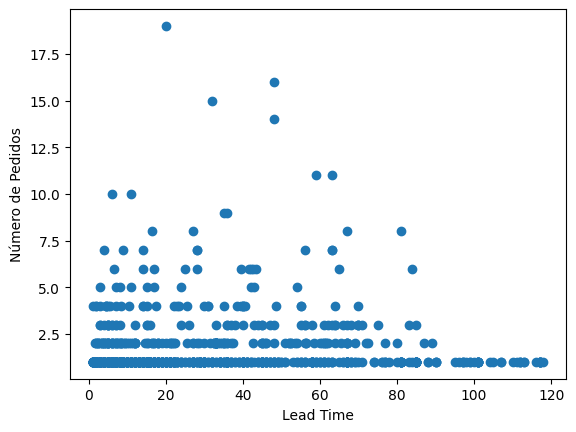

In [ ]:
import matplotlib.pyplot as plt


compras['Identificador'] = compras['Ref. Cruzada/Prop.'].astype(str).str.replace(r'\.0$', '', regex=True).str.replace(r',0$', '', regex=True).str.strip()
entradas['Identificador'] = entradas['Material'].astype(str).str.replace(r'\.0$', '', regex=True).str.replace(r',0$', '', regex=True).str.strip()

nemos_comunes = set(compras['Identificador']).intersection(set(entradas['Identificador']))

compras['Fecha de compra'] = pd.to_datetime(compras['Fecha del pedido'], format = 'mixed', dayfirst = True, errors='coerce').dt.normalize()
entradas['Fecha de entrada'] = pd.to_datetime(entradas['Fecha contabiliz.'], format = 'mixed', dayfirst = True, errors='coerce').dt.normalize()

compras = compras.dropna(subset=['Identificador', 'Fecha de compra'])
entradas = entradas.dropna(subset=['Identificador', 'Fecha de entrada'])

compras = compras.sort_values(by='Fecha de compra')
entradas = entradas.sort_values(by='Fecha de entrada')

cruce = pd.merge_asof(compras, entradas, by = 'Identificador', left_on = 'Fecha de compra', right_on='Fecha de entrada', direction = 'forward', tolerance=pd.Timedelta(days=120))
cruce = cruce.dropna(subset=['Fecha de entrada'])
cruce['Lead time'] = (cruce['Fecha de entrada'] - cruce['Fecha de compra']).dt.days
cruce['Lead time'] = cruce['Lead time'].astype(int)
cruce = cruce[cruce['Lead time'] > 0]

print(len(cruce))

print(cruce.head())

# --- SUSTITUYE DESDE AQUÍ HASTA EL FINAL DE TU SCRIPT ---

# Agrupamos calculando LA MEDIANA y además CONTANDO el número de pedidos
promedio = cruce.groupby('Identificador')['Lead time'].agg(['median', 'count']).reset_index()

# Renombramos las columnas para que todo tu código posterior siga funcionando igual
promedio.rename(columns={'median': 'Lead time', 'count': 'Numero_de_pedidos'}, inplace=True)

# Redondeamos y ordenamos por los más lentos primero
promedio['Lead time'] = promedio['Lead time'].round(2)
promedio.sort_values(by='Lead time', ascending=False, inplace=True)

print("Total de Nemos analizados:", len(promedio))

# Vamos a ver los más críticos (los que tardan más de 100 días)
sospechosos = promedio[promedio['Lead time'] > 100]

print("\n🔍 SOSPECHOSOS (Lead Time > 100 días):")
print(sospechosos)

plt.scatter(promedio[promedio['Numero_de_pedidos']<20]['Lead time'], promedio[promedio['Numero_de_pedidos']<20]['Numero_de_pedidos'])
plt.xlabel('Lead Time')
plt.ylabel('Número de Pedidos')
plt.show()

# Eliminamos la columna 'Numero_de_pedidos' porque ya no la necesitamos
promedio = promedio.drop(columns=['Numero_de_pedidos'])



# Punto de pedido

Usamos la fórmula:

 PP = Demanda * Lead time + Seguridad

Calculamos la demanda diaria:

In [ ]:
salidas['Material'] = salidas['Material'].astype(str).replace(r'\.0$', '', regex=True).str.replace(r',0$', '', regex=True).str.strip()
salidas['Cantidad'] = pd.to_numeric(salidas['Cantidad'], errors='coerce').fillna(0)
fecha0 = salidas['Fecha contabiliz.'].min()
fecha1 = salidas['Fecha contabiliz.'].max()
dias = (fecha1 - fecha0).days

print(dias)

demanda = salidas.groupby('Material')['Cantidad'].sum().reset_index()
demanda['Demanda diaria'] = demanda['Cantidad'] / dias

demanda = demanda.sort_values(by='Demanda diaria', ascending=False).reset_index(drop=True)

297


Calculamos el Stock de seguridad así:

Stock = Demanda * Cobertura

La cobertura depende de la matriz ABC-XYZ.

In [ ]:
promedio = promedio.rename(columns={'Identificador': 'Material'})
abc['Material'] = abc['Material'].astype(str).replace(r'\.0$', '', regex=True).str.replace(r',0$', '', regex=True).str.strip()
xyz['Material'] = xyz['Material'].astype(str).replace(r'\.0$', '', regex=True).str.replace(r',0$', '', regex=True).str.strip()
puntopedido = pd.merge(demanda, promedio, on='Material', how='left')
puntopedido = pd.merge(puntopedido, abc[['Material', 'Descripcion del material', 'Clasificacion ABC', 'Precio']], on='Material', how='left')
puntopedido = pd.merge(puntopedido, xyz[['Material', 'Clasificacion XYZ']], on='Material', how='left')
mediana = puntopedido['Lead time'].median()
puntopedido['Lead time'] = puntopedido['Lead time'].fillna(mediana)

puntopedido.head()
puntopedido['Precio'] = puntopedido['Precio'].fillna(0)


In [ ]:
import numpy as np
def cobertura(df):
  abc = str(df['Clasificacion ABC']).strip().upper()
  xyz = str(df['Clasificacion XYZ']).strip().upper()

  # Regla de negocio (El riesgo financiero)
  if abc == 'A' and xyz == 'X': return 3
  elif abc == 'A' and xyz == 'Y': return 7
  elif abc == 'A' and xyz == 'Z': return 0

  elif abc == 'B' and xyz == 'X': return 7
  elif abc == 'B' and xyz == 'Y': return 15
  elif abc == 'B' and xyz == 'Z': return 0

  elif abc == 'C' and xyz == 'X': return 15
  elif abc == 'C' and xyz == 'Y': return 30
  elif abc == 'C' and xyz == 'Z': return 0

  else: return 0

def cantidad_pedido(df):
  demanda = df['Demanda diaria']
  abc = str(df['Clasificacion ABC']).strip().upper()

  # Si la pieza no tiene consumo (0), pedimos 1 por defecto
  if demanda <= 0:
      return 1

  # Regla de negocio basada en el dinero (Días de cobertura de compra)
  if abc == 'A':
      cantidad = demanda * 30  # Compramos para 1 mes
  elif abc == 'B':
      cantidad = demanda * 60  # Compramos para 2 meses
  elif abc == 'C':
      cantidad = demanda * 180 # Compramos para medio año
  else:
      cantidad = demanda * 30  # Por defecto 1 mes

  return cantidad

puntopedido['Cantidad a comprar'] = puntopedido.apply(cantidad_pedido, axis=1)
puntopedido['Cantidad a comprar'] = np.floor(puntopedido['Cantidad a comprar']).astype(int)
puntopedido['Cobertura'] = puntopedido.apply(cobertura, axis=1)
puntopedido['Stock de seguridad'] = np.floor(puntopedido['Demanda diaria'] * puntopedido['Cobertura']).astype(int)
puntopedido['Punto de pedido'] = np.floor(puntopedido['Demanda diaria'] * puntopedido['Lead time'] + puntopedido['Stock de seguridad']).astype(int)

puntopedido.loc[(puntopedido['Demanda diaria'] > 0) &
               (puntopedido['Clasificacion XYZ'].str.upper() != 'Z') &
               (puntopedido['Punto de pedido'] < 1), 'Punto de pedido'] = 1


print(puntopedido.head())
puntopedido.to_excel('Punto_pedido.xlsx', index = False)

puntopedido['Valor de stock'] = puntopedido['Precio'] * puntopedido['Stock de seguridad']

# Redondeamos las columnas de dinero a 2 decimales para que queden limpias en Excel
puntopedido['Precio'] = puntopedido['Precio'].round(2)
puntopedido['Valor de stock'] = puntopedido['Valor de stock'].round(2)


  Material  Cantidad  Demanda diaria  Lead time  \
0  9007584    3174.0       10.686869       39.5   
1  9007581    2779.0        9.356902       43.0   
2  9005203    2757.0        9.282828       39.5   
3  9005204    1075.0        3.619529       39.5   
4  9035239     995.0        3.350168       23.0   

                   Descripcion del material Clasificacion ABC     Precio  \
0    JUNTA SILICONA CLAMP 1 1/2" 40RXPX-150                 A   1.722883   
1  JUNTA SILICONA CLAMP 1/2" REF: 42RXPX-05                 A   1.455005   
2          MEMBRANA GEMU MG8 EPDM 600/8M/17                 A  14.859420   
3        MEMBRANA GEMU MG25 EPDM 600/25M/17                 A  30.141814   
4              JUNTA CLAMP GYLON 1-1/2 BLUE                 A   7.559839   

  Clasificacion XYZ  Cantidad a comprar  Cobertura  Stock de seguridad  \
0                 X                 320          3                  32   
1                 X                 280          3                  28   
2             

# Análisis preventivo



In [ ]:
fechas = pd.read_excel('fechas.XLSX')
# Para leer la lista de Hojas de Ruta
rutas = pd.read_excel('datos.xlsx', sheet_name='Nemos a hojas de ruta', engine='openpyxl')
rutas.rename(columns={'PlnMant': 'Plan mantenimiento', 'Nemo': 'Material'}, inplace=True)
puntopedido['Material'] = pd.to_numeric(puntopedido['Material'], errors='coerce').astype('Int64')

rutas['Material'] = pd.to_numeric(rutas['Material'], errors='coerce').astype('Int64')
rutas['Plan mantenimiento'] = pd.to_numeric(rutas['Plan mantenimiento'], errors='coerce').astype('Int64')
fechas['Plan mantenimiento'] = pd.to_numeric(fechas['Plan mantenimiento'], errors='coerce').astype('Int64')

fechas['Fecha planificada'] = pd.to_datetime(fechas['Fecha planificada'], format='mixed', dayfirst=True, errors='coerce')

preventivo = pd.merge(rutas, fechas[['Plan mantenimiento', 'Fecha planificada']], on='Plan mantenimiento', how='inner')
preventivo = preventivo.dropna(subset=['Fecha planificada'])
preventivo = pd.merge(preventivo, puntopedido[['Material', 'Lead time']], on='Material', how='left')


preventivo['Lead time'] = preventivo['Lead time'].fillna(35)

preventivo['Fecha de aviso'] = preventivo['Fecha planificada'] - pd.to_timedelta(preventivo['Lead time'], unit='d')
preventivo = preventivo.sort_values(by='Fecha de aviso')


print(preventivo.head())
print(puntopedido.info())


     GrpHRuta Equipo                    Número de equipo  S   Ce.coste  \
1170   FR6686   6686        Instal API 03 Veolia CB4/HV5  S  1000000.0   
1755   FR9574   9574        Instal API 04 Veolia CB5/VV4  S  1000000.0   
2063  FR11851  11851           Instal API 06 Veolia VIF2  S  1440002.0   
1045  TPM6155   6155       Fermentador 22 Sartorius 100L  S  1110004.0   
2859  FR17090  17090  Homogeneizador 18 GEA Niro Soavi H  S  1440003.0   

      Material        Componente de lista de materiales ABC  Cantidad  UM  \
1170   9023069   MEMBRANA EPDM/PTFE DN25 BURKERT 677677   A         3  UN   
1755   9023069   MEMBRANA EPDM/PTFE DN25 BURKERT 677677   A         4  UN   
2063   9023069   MEMBRANA EPDM/PTFE DN25 BURKERT 677677   A         2  UN   
1045   9023048  MEMBRANA DIAFRAGMA TOMA MUEST SARTORIUS   A         1  UN   
2859   9009930   JUNTA 9531-4205-591 CM5782/15466/13826   A         4  UN   

      Punto pedido  Tam.lote fijo  Plan mantenimiento Fecha planificada  \
1170             

In [ ]:
print(sum(puntopedido['Valor de stock']))

5492.23


In [ ]:
puntopedido = puntopedido.drop(['Cantidad'], axis=1, errors='ignore')
preventivo = preventivo.sort_values(by = 'Fecha planificada')
primera_fecha = preventivo.groupby('Material').first().reset_index()
preventivo_cols = ['Material', 'Equipo', 'Número de equipo', 'Fecha planificada', 'Fecha de aviso', 'Cantidad', 'Plan mantenimiento']
primera_fecha = primera_fecha[preventivo_cols]

primera_fecha = primera_fecha.rename(columns = {'Cantidad': 'Cantidad preventiva'})
unificado = pd.merge(puntopedido, primera_fecha, on='Material', how='left')
unificado = unificado.sort_values(by='Fecha planificada')

unificado['Cantidad preventiva'] = unificado['Cantidad preventiva'].fillna(0)

print(unificado.info())
print(unificado.head())

<class 'pandas.core.frame.DataFrame'>
Index: 841 entries, 270 to 840
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Material                  841 non-null    Int64         
 1   Demanda diaria            841 non-null    float64       
 2   Lead time                 841 non-null    float64       
 3   Descripcion del material  841 non-null    object        
 4   Clasificacion ABC         841 non-null    object        
 5   Precio                    841 non-null    float64       
 6   Clasificacion XYZ         841 non-null    object        
 7   Cantidad a comprar        841 non-null    int64         
 8   Cobertura                 841 non-null    int64         
 9   Stock de seguridad        841 non-null    int64         
 10  Punto de pedido           841 non-null    int64         
 11  Valor de stock            841 non-null    float64       
 12  Equipo                   

In [ ]:

# 1. Creamos el DataFrame del Glosario/Diccionario
glosario_data = {
    'Columna': [
        'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L',
        'M', 'N', 'O', 'P', 'Q',
    ],
    'Nombre': [
        'Material', 'Descripcion del material', 'Demanda diaria', 'Lead time',
        'Clasificacion ABC', 'Precio', 'Clasificacion XYZ', 'Cantidad a comprar', 'Stock de seguridad', 'Punto de pedido', 'Valor de stock',
        'Equipo', 'Número de equipo', 'Fecha planificada', 'Fecha de aviso',
        'Cantidad preventiva', 'Plan mantenimiento'
    ],
    'Descripción': [
        'Código Nemo / ID de la pieza en el sistema.',
        'Descripción de la pieza.',
        'Es el promedio de unidades que la fábrica gasta cada día. Cantidad total consumida dividida entre los días del periodo.',
        'El tiempo de entrega en días que tarda el proveedor en traer la pieza desde que se le hace el pedido hasta que entra en el almacén. Está basado en la mediana para ignorar pedidos erróneos.',
        'Categoría financiera de la pieza. A: Muy caras. Representan el 80% del valor total acumulado del almacén. B: Coste intermedio. Representan hasta el 95% del valor acumulado. C: Muy baratas. El 5% restante.',
        'Precio unitario de compra de la pieza en euros.',
        'Categoría de previsibilidad. X: Consumo muy regular. Se consumen al menos 7 meses al año. Y: Consumo fluctuante. Se consumen entre 3 y 6 meses. Z: Consumo esporádico. Se consumen menos de 3 meses al año.',
        'Cantidad de piezas que se debe pedir al proveedor cuando salta la alarma del punto pedido. Se calcula para cubrir 1 mes (A), 2 meses (B) o 6 meses (C) según su impacto financiero.',
        'Cantidad mínima que siempre debe quedar para absorber imprevistos. Se calcula como la demanda durante los días de cobertura (Demanda diaria * Cobertura).',
        'El nivel de stock correctivo base en el que se debe lanzar el pedido. Se calcula como Demanda diaria * Lead time + Stock de seguridad.',
        'El coste total en euros de tener ese stock de seguridad inmovilizado en el almacén.',
        'ID de la máquina o equipo en el sistema.',
        'Nombre de la máquina, línea o sistema funcional al que está asociado el mantenimiento preventivo más próximo.',

        'Fecha programada en el calendario para llevar a cabo la próxima revisión o intervención preventiva.',
        'Fecha en la que el sistema genera la alerta para pedir los materiales que hacen falta para la próxima revisión.',
        'Número de unidades específicas de la pieza que se van a consumir en el próximo mantenimiento preventivo programado.',
        'Código identificador de la hoja de ruta, instrucción u orden de mantenimiento asignada a esa intervención.'
    ]
}
df_glosario = pd.DataFrame(glosario_data)

nombre_archivo = 'Optimizacion_Stock.xlsx'

# 2. Guardamos las pestañas en el orden que queremos que aparezcan
with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:
    # Al poner 'Diccionario_Datos' primero, aparecerá como la primera pestaña a la izquierda
    df_glosario.to_excel(writer, sheet_name='Descripcion_columnas', index=False)
    unificado.to_excel(writer, sheet_name='Correctivo_Preventivo', index=False)
    # 3. APLICAR FORMATO Y DISEÑO PROFESIONAL
    # Definimos los estilos (Fondo gris oscuro y letra blanca en negrita para la cabecera)
    estilo_cabecera = Font(name='Calibri', size=11, bold=True, color='FFFFFF')
    fondo_cabecera = PatternFill(start_color='4F5D75', end_color='4F5D75', fill_type='solid') # Gris azulado elegante
    alineacion_centro = Alignment(horizontal='center', vertical='center')

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]

        # Aplicamos formato a la primera fila (Cabecera) de cada pestaña
        for cell in worksheet[1]:
            cell.font = estilo_cabecera
            cell.fill = fondo_cabecera
            if sheet_name == 'Descripcion_columnas' and cell.column in [1, 2]:
                cell.alignment = alineacion_centro

        # Auto-ajustamos el ancho de las columnas para que no salgan los '#######'
        for col in worksheet.columns:
            # Buscamos el texto más largo de la columna
            max_len = max(len(str(cell.value or '')) for cell in col)
            col_letter = col[0].column_letter

            # Ajuste especial para la columna de descripción del diccionario (que es muy larga)
            if sheet_name == 'Descripcion_columnas' and col_letter == 'C':
                worksheet.column_dimensions[col_letter].width = 80 # Ancho fijo grande para que se lea bien
            else:
                worksheet.column_dimensions[col_letter].width = max(max_len + 3, 12)

print(f"Archivo '{nombre_archivo}' generado.")
print("La pestaña 'Diccionario_Datos' ha quedado colocada al principio y con formato profesional.")

🚀 ¡Espectacular! Archivo 'Optimizacion_Stock.xlsx' generado.
La pestaña 'Diccionario_Datos' ha quedado colocada al principio y con formato profesional.
